<a href="https://colab.research.google.com/github/TejasKayarkar03/Pattern-Recognition-Lab/blob/main/PR_CM23045_Pr9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kagglehub

In [ ]:
import os
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "omkargurav/face-mask-dataset"
)

print("Dataset downloaded at:")
print(path)

Using Colab cache for faster access to the 'face-mask-dataset' dataset.
Dataset downloaded at:
/kaggle/input/face-mask-dataset


In [ ]:
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

    subindent = ' ' * 4 * (level + 1)

    for file in files[:5]:
        print(f"{subindent}{file}")

face-mask-dataset/
    data/
        without_mask/
            without_mask_3248.jpg
            without_mask_2803.jpg
            without_mask_650.jpg
            without_mask_2060.jpg
            without_mask_559.jpg
        with_mask/
            with_mask_3326.jpg
            with_mask_3139.jpg
            with_mask_696.jpg
            with_mask_2867.jpg
            with_mask_39.jpg


In [ ]:
dataset_dir = None

for root, dirs, files in os.walk(path):
    if "with_mask" in dirs and "without_mask" in dirs:
        dataset_dir = root
        break

print("Dataset directory:", dataset_dir)

Dataset directory: /kaggle/input/face-mask-dataset/data


In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

In [ ]:
train_data = datagen.flow_from_directory(
    dataset_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

Found 6043 images belonging to 2 classes.


In [ ]:
validation_data = datagen.flow_from_directory(
    dataset_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 1510 images belonging to 2 classes.


In [ ]:
print(train_data.class_indices)

{'with_mask': 0, 'without_mask': 1}


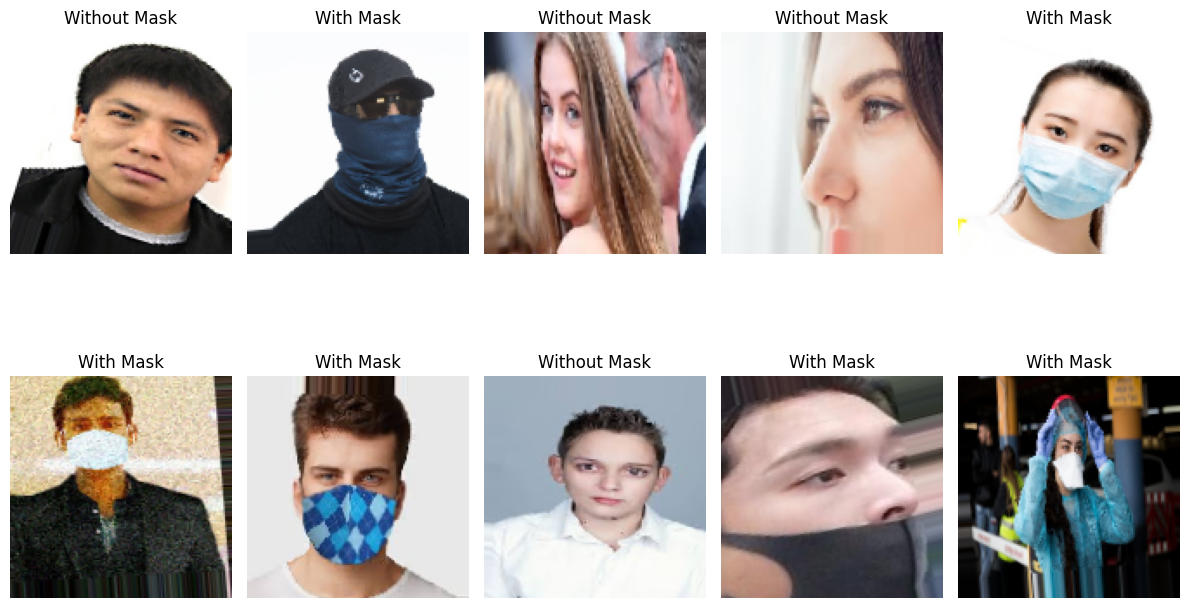

In [ ]:
images, labels = next(train_data)

plt.figure(figsize=(12, 8))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(images[i])

    if labels[i] == 0:
        plt.title("With Mask")
    else:
        plt.title("Without Mask")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model = Sequential([

    Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),

    MaxPooling2D(pool_size=(2, 2)),


    Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2, 2)),


    Conv2D(
        128,
        (3, 3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2, 2)),


    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=15
)

Epoch 1/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 53s 282ms/step - accuracy: 0.8514 - loss: 0.3389 - val_accuracy: 0.9040 - val_loss: 0.2583
Epoch 2/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 78s 259ms/step - accuracy: 0.8775 - loss: 0.2939 - val_accuracy: 0.8901 - val_loss: 0.2899
Epoch 3/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 82s 259ms/step - accuracy: 0.8852 - loss: 0.2763 - val_accuracy: 0.9278 - val_loss: 0.2152
Epoch 4/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 50s 264ms/step - accuracy: 0.8951 - loss: 0.2497 - val_accuracy: 0.9391 - val_loss: 0.1900
Epoch 5/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 48s 254ms/step - accuracy: 0.9164 - loss: 0.2173 - val_accuracy: 0.9338 - val_loss: 0.1845
Epoch 6/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 47s 248ms/step - accuracy: 0.9164 - loss: 0.2076 - val_accuracy: 0.9457 - val_loss: 0.1834
Epoch 7/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 48s 254ms/step - accuracy: 0.9287 - loss: 0.1882 - val_accuracy: 0.9404 - val_loss: 0.1653
Epoch 8/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 48s 256ms/step - accuracy: 0.9345 - loss: 0

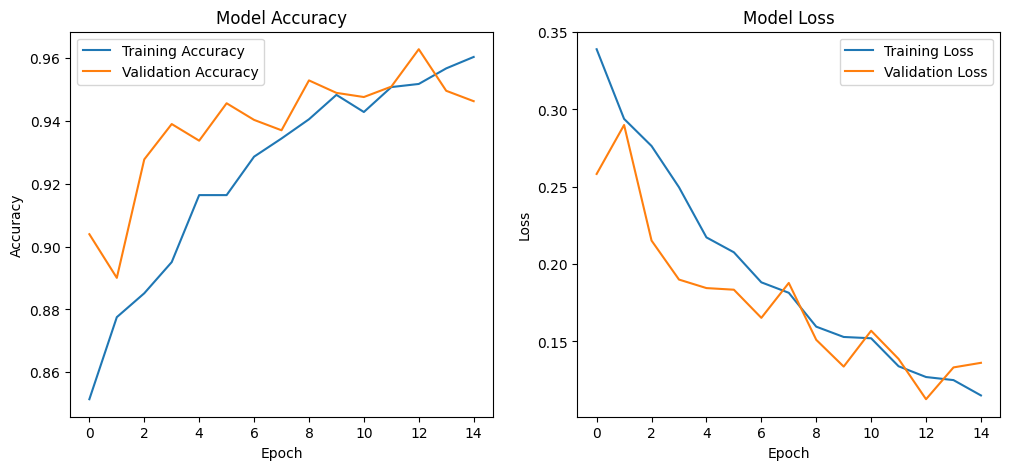

In [ ]:
plt.figure(figsize=(12, 5))

# Accuracy Graph
plt.subplot(1, 2, 1)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


# Loss Graph
plt.subplot(1, 2, 2)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
loss, accuracy = model.evaluate(validation_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 173ms/step - accuracy: 0.9417 - loss: 0.1449
Validation Loss: 0.14488080143928528
Validation Accuracy: 0.9417218565940857


In [ ]:
validation_data.reset()

predictions = model.predict(validation_data)

predicted_classes = (predictions > 0.5).astype(int).flatten()

true_classes = validation_data.classes

48/48 ━━━━━━━━━━━━━━━━━━━━ 14s 284ms/step


In [ ]:
print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=["With Mask", "Without Mask"]
    )
)

              precision    recall  f1-score   support

   With Mask       0.96      0.95      0.95       745
Without Mask       0.95      0.96      0.96       765

    accuracy                           0.96      1510
   macro avg       0.96      0.96      0.96      1510
weighted avg       0.96      0.96      0.96      1510



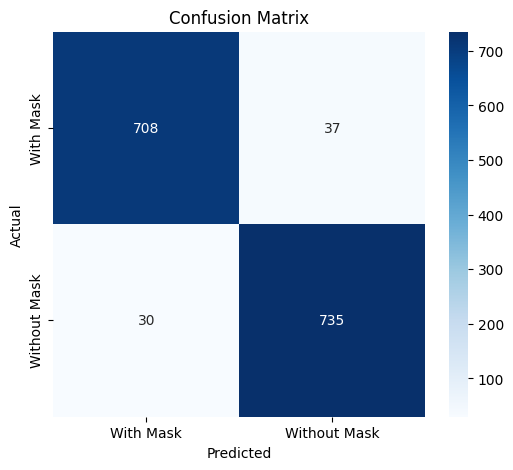

In [ ]:
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["With Mask", "Without Mask"],
    yticklabels=["With Mask", "Without Mask"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving young-men-face-mask-isolated-260nw-1674252700.webp to young-men-face-mask-isolated-260nw-1674252700.webp


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 954ms/step
Prediction: WITH MASK 😷


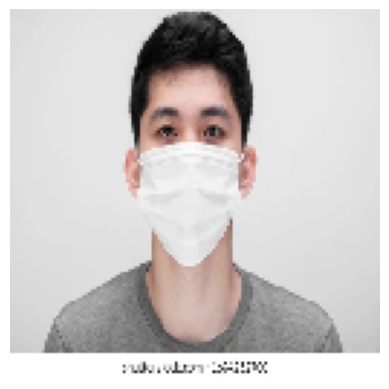

In [ ]:
from tensorflow.keras.preprocessing import image

file_name = list(uploaded.keys())[0]

img = image.load_img(
    file_name,
    target_size=(IMG_SIZE, IMG_SIZE)
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0
)

img_array = img_array / 255.0

prediction = model.predict(img_array)

plt.imshow(img)
plt.axis("off")

if prediction[0][0] > 0.5:
    print("Prediction: WITHOUT MASK ❌")
else:
    print("Prediction: WITH MASK 😷")

In [ ]:
model.save("face_mask_detection_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving images (2).jpeg to images (2).jpeg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Prediction: WITHOUT MASK ❌


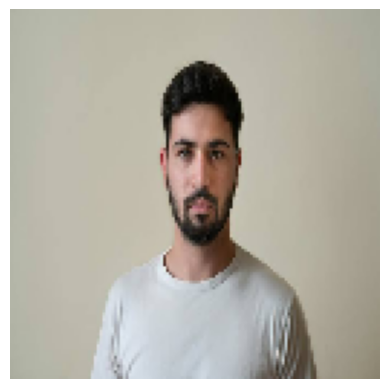

In [ ]:
from tensorflow.keras.preprocessing import image

file_name = list(uploaded.keys())[0]

img = image.load_img(
    file_name,
    target_size=(IMG_SIZE, IMG_SIZE)
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0
)

img_array = img_array / 255.0

prediction = model.predict(img_array)

plt.imshow(img)
plt.axis("off")

if prediction[0][0] > 0.5:
    print("Prediction: WITHOUT MASK ❌")
else:
    print("Prediction: WITH MASK 😷")